In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

 # Necessary libraries for data analysis and visualization

In [2]:
df = pd.read_csv('diabetes.csv') #The dataset we use

In [3]:
print(df.head()) # It displays the first 5 rows of the dataset to get an overview of the data
print(df.info()) # It shows some general information about the dataset

# I made this part to see how the dataset looks like before starting the main code

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

In [4]:
# I made a loop through each column in the dataset EXCEPT the target column 'Outcome' by using df.columns[:-1] (to exclude the last column which is 'Outcome')

for column in df.columns[:-1]:
    print(f"Analysis for {column}:")
    print(f"Mean: {df[column].mean()}") # Average value
    print(f"Median: {df[column].median()}") # Middle value when sorted
    print(f"Mode: {df[column].mode()[0]}") # Most frequent value
    # df[column].mode() returns a Series, so I took the first value by using[0]
    print(f"Standard Deviation: {df[column].std()}") # How spread out the values are
    print(f"Variance: {df[column].var()}") # Standard Deviation squared / Variance
    print(f"Range of values: {df[column].max() - df[column].min()}") # Max - Min values
    print("\n") #I printed a new line for better readability between columns (it's not necessary)

Analysis for Pregnancies:
Mean: 3.8450520833333335
Median: 3.0
Mode: 1
Standard Deviation: 3.3695780626988694
Variance: 11.354056320621465
Range of values: 17


Analysis for Glucose:
Mean: 120.89453125
Median: 117.0
Mode: 99
Standard Deviation: 31.97261819513622
Variance: 1022.2483142519557
Range of values: 199


Analysis for BloodPressure:
Mean: 69.10546875
Median: 72.0
Mode: 70
Standard Deviation: 19.355807170644777
Variance: 374.6472712271838
Range of values: 122


Analysis for SkinThickness:
Mean: 20.536458333333332
Median: 23.0
Mode: 0
Standard Deviation: 15.952217567727637
Variance: 254.47324532811822
Range of values: 99


Analysis for Insulin:
Mean: 79.79947916666667
Median: 30.5
Mode: 0
Standard Deviation: 115.24400235133817
Variance: 13281.180077955238
Range of values: 846


Analysis for BMI:
Mean: 31.992578124999998
Median: 32.0
Mode: 32.0
Standard Deviation: 7.884160320375446
Variance: 62.15998395738266
Range of values: 67.1


Analysis for DiabetesPedigreeFunction:
Mean: 0.4

In [5]:
# There i droped the 'Outcome' itself to avoid trivial correlation of 1.0
correlations = df.corr()['Outcome'].drop('Outcome')
print(correlations)

Pregnancies                 0.221898
Glucose                     0.466581
BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
BMI                         0.292695
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Name: Outcome, dtype: float64


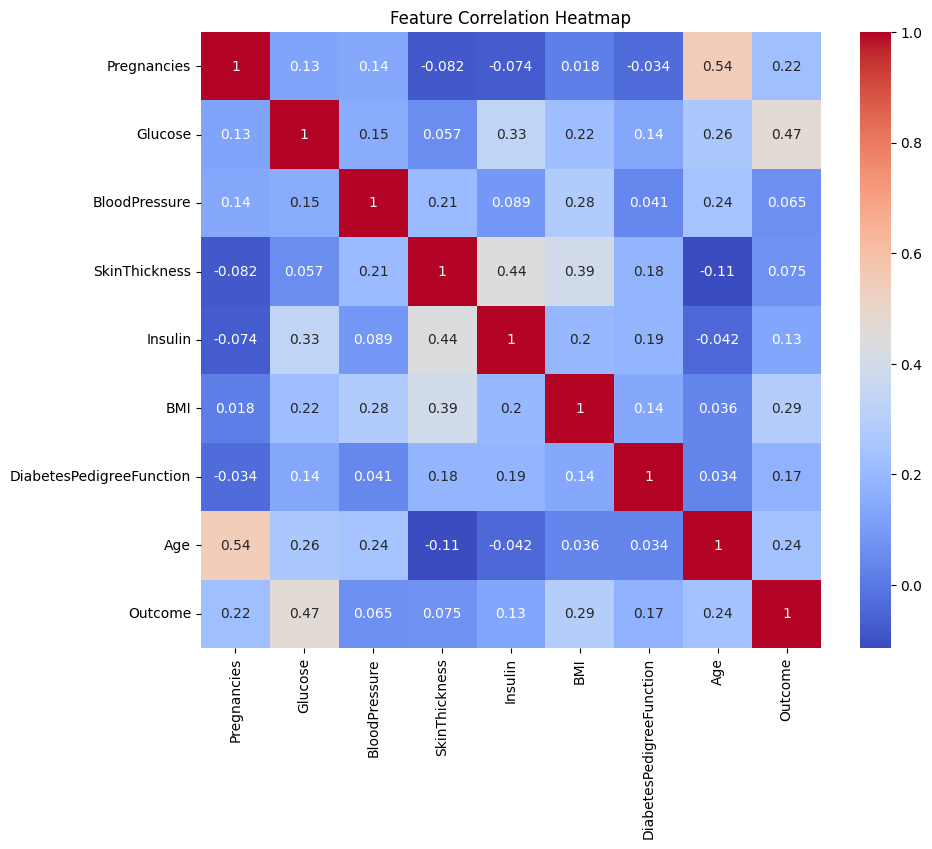

In [6]:
# I used a heatmap to visualize the correlation matrix to see the strength of correlations clearer
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [7]:
# Correlation Analysis with the Target Column 'Outcome':
#
# In this dataset, the target column 'Outcome' shows whether a person has diabetes (1) or not (0).
#
# After checking the correlation values, the feature that has the strongest connection with the Outcome is 'Glucose',
# with a correlation of around 0.47. This makes perfect sense because high blood sugar levels are one of the main signs of diabetes.
#
# Other features that show a decent correlation are:
# BMI (~0.29) — since being overweight or obese is a common risk factor for diabetes.
# Age (~0.24) — older people are more likely to develop diabetes.
# Pregnancies (~0.22) — having more pregnancies can sometimes increase the risk, especially if someone had gestational diabetes before.
#
# The rest of the features like BloodPressure or SkinThickness don’t have a strong correlation with diabetes in this dataset.
# This doesn’t mean they’re not important in real life — but here, they don’t seem to directly influence the Outcome as much as the others.
#
# Overall, the results match what we know from medical research — glucose levels, BMI, and age are some of the most common indicators of diabetes.

# Here is a site that confirms my small research and explains the diabetes topic
# https://www.nhlbi.nih.gov/resources/what-diabetes-fact-sheet